# Stationary versus movement stimulus responses

Compare responses to the last 15 ms stimulus before center-port exit and the first 15 ms stimulus during the movement to the response port. Spikes and hardware events come from the database in the shared ephys clock.

## Set up the tutorial

In [1]:
import warnings

import matplotlib.pyplot as plt
from scipy.stats import sem
from spks.event_aligned import population_peth
from spks.viz import plot_event_aligned_raster

warnings.filterwarnings("ignore", category=UserWarning, module="datajoint.plugin")

plt.rcParams["text.usetex"] = False
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = 'svg'
%matplotlib widget
%load_ext autoreload
%autoreload 2

## Load synchronized trials and stable stimulus-responsive units

In [2]:
from labdata_plugin.schema import StimulusResponse
from thesis.ephys.analyses.stim_responses_by_locomotion import (
    extract_paired_stim_anchors,
    load_trial_classification,
)
from thesis.ephys.units import fetch_unit_table

subject = "GRB006"
session = "20240821_121447"
unit_criteria_id = 1
stability_param_id = 0
stim_response_param_id = 0
unit_id = 20

trial_classification = load_trial_classification(subject, session)
stationary_events_s, movement_events_s = extract_paired_stim_anchors(
    trial_classification
)

unit_table = fetch_unit_table(subject, session, unit_criteria_id, stability_param_id)
response_query = {
    "subject_name": subject,
    "session_name": session,
    "unit_criteria_id": unit_criteria_id,
    "stim_response_param_id": stim_response_param_id,
    "response_type": "excited",
}
excited_unit_ids = set((StimulusResponse.Unit & response_query).fetch("unit_id"))
unit_table = unit_table[unit_table["unit_id"].isin(excited_unit_ids)].sort_values(
    "unit_id"
)
if unit_id not in excited_unit_ids:
    raise ValueError(f"Unit {unit_id} does not pass the selected filters.")

unit_ids = unit_table["unit_id"].astype(int).tolist()
spike_times_by_unit = dict(zip(unit_ids, unit_table["spike_times_s"], strict=True))
all_spike_times_s = [spike_times_by_unit[current_id] for current_id in unit_ids]
unit_index = unit_ids.index(unit_id)

print(
    f"Loaded {len(unit_ids)} stable stimulus-responsive units and "
    f"{len(stationary_events_s)} paired trials."
)

[2026-08-24 19:17:28,578][INFO]: DataJoint 0.14.8 connected to rojasbowe@churchland-data.cmojfwfr0b9t.us-west-2.rds.amazonaws.com:3306


Loaded 23 stable stimulus-responsive units and 283 paired trials.


## Choose the alignment window

In [3]:
binwidth_ms = 10
pre_seconds = 0.1
post_seconds = 0.15
stationary_color = "#377EB8"
movement_color = "#E41A1C"

## Plot paired rasters for one unit

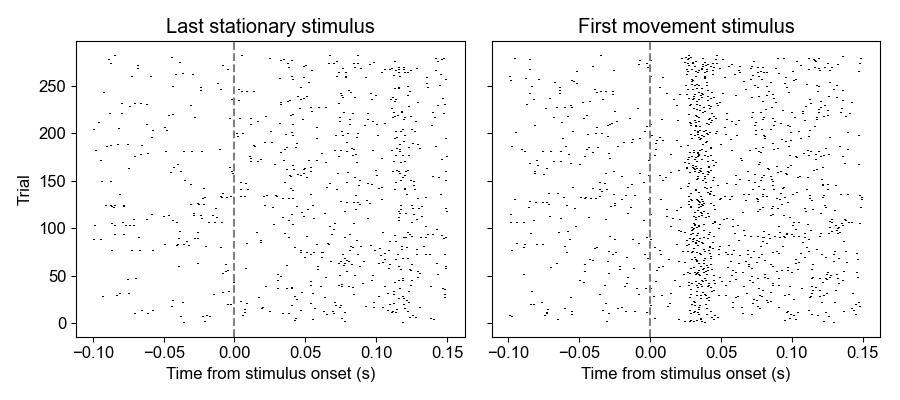

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, event_times_s, label in zip(
    axes,
    (stationary_events_s, movement_events_s),
    ("Last stationary stimulus", "First movement stimulus"),
    strict=True,
):
    plot_event_aligned_raster(
        event_times=event_times_s,
        spike_times=spike_times_by_unit[unit_id],
        pre_seconds=pre_seconds,
        post_seconds=post_seconds,
        ax=ax,
    )
    ax.axvline(0, color="0.5", linestyle="--")
    ax.set_title(label)
    ax.set_xlabel("Time from stimulus onset (s)")
axes[0].set_ylabel("Trial")
fig.tight_layout()

## Compute stationary and movement PETHs

In [5]:
stationary_peth, bin_edges, _ = population_peth(
    all_spike_times=all_spike_times_s,
    alignment_times=stationary_events_s,
    pre_seconds=pre_seconds,
    post_seconds=post_seconds,
    binwidth_ms=binwidth_ms,
)
movement_peth, _, _ = population_peth(
    all_spike_times=all_spike_times_s,
    alignment_times=movement_events_s,
    pre_seconds=pre_seconds,
    post_seconds=post_seconds,
    binwidth_ms=binwidth_ms,
)
stationary_peth = stationary_peth / (binwidth_ms / 1000)
movement_peth = movement_peth / (binwidth_ms / 1000)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

## Compare the trial-averaged responses for one unit

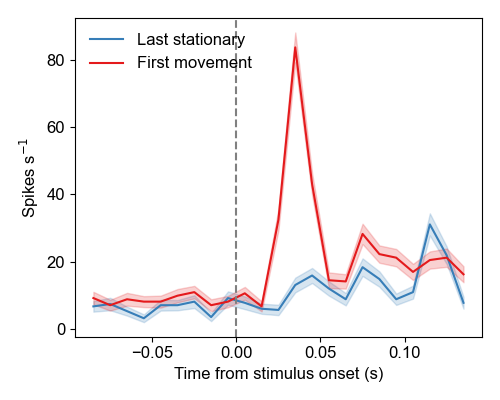

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
for peth, color, label in (
    (stationary_peth, stationary_color, "Last stationary"),
    (movement_peth, movement_color, "First movement"),
):
    unit_peth = peth[unit_index]
    mean_peth = unit_peth.mean(axis=0)
    sem_peth = sem(unit_peth, axis=0)
    ax.plot(bin_centers, mean_peth, color=color, label=label)
    ax.fill_between(
        bin_centers,
        mean_peth - sem_peth,
        mean_peth + sem_peth,
        color=color,
        alpha=0.2,
    )
ax.axvline(0, color="0.5", linestyle="--")
ax.set_xlabel("Time from stimulus onset (s)")
ax.set_ylabel("Spikes s$^{-1}$")
ax.legend(frameon=False)
fig.tight_layout()

## Compare baseline-corrected peak responses across units

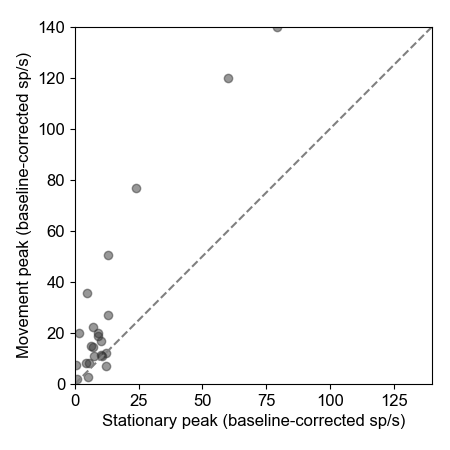

In [7]:
stationary_mean = stationary_peth.mean(axis=1)
movement_mean = movement_peth.mean(axis=1)
baseline_bins = (bin_centers >= -0.04) & (bin_centers < 0.0)
response_bins = (bin_centers >= 0.03) & (bin_centers < 0.12)

# Both conditions use the stationary pre-stimulus baseline.
baseline = stationary_mean[:, baseline_bins].mean(axis=1)
stationary_peaks = (stationary_mean[:, response_bins] - baseline[:, None]).max(axis=1)
movement_peaks = (movement_mean[:, response_bins] - baseline[:, None]).max(axis=1)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(stationary_peaks, movement_peaks, color="0.2", alpha=0.5)
lower = min(0.0, stationary_peaks.min(), movement_peaks.min())
upper = max(stationary_peaks.max(), movement_peaks.max())
ax.plot([lower, upper], [lower, upper], color="0.5", linestyle="--")
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_aspect("equal")
ax.set_xlabel("Stationary peak (baseline-corrected sp/s)")
ax.set_ylabel("Movement peak (baseline-corrected sp/s)")
fig.tight_layout()